# 02 - Feature Engineering & Selection
**MedPilot - Disease Prediction & Medicine Recommendation System**

Builds on `01_eda.ipynb`'s findings: common symptoms are the least discriminative,
rare symptoms carry the most diagnostic signal. This notebook engineers new
features from the severity reference table, tests feature usefulness statistically
via mutual information, and produces the final train/test split for modelling.

## 1. Load cleaned data (output of `src/data_prep.py`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100

train = pd.read_csv("../data/processed/training_clean.csv")
severity = pd.read_csv("../data/processed/severity_clean.csv")

symptom_cols = [c for c in train.columns if c != "prognosis"]
print("Rows:", len(train), "| Symptom features:", len(symptom_cols), "| Diseases:", train["prognosis"].nunique())

Rows: 4920 | Symptom features: 131 | Diseases: 41


## 2. Feature Engineering

Two new features derived from combining the symptom flags with the severity
reference table - genuinely new signal, not present as columns in the raw data.

In [2]:
# Build a symptom -> severity weight lookup, handling the fluid_overload_2
# collision documented in the EDA notebook (assumption: second weight applies)
severity_map = dict(zip(severity["Symptom"], severity["weight"]))
if "fluid_overload_2" not in severity_map:
    # apply the same documented assumption as 01_eda.ipynb
    fo_weights = severity[severity["Symptom"] == "fluid_overload"]["weight"].tolist()
    severity_map["fluid_overload_2"] = fo_weights[-1] if fo_weights else severity["weight"].median()

weight_vector = np.array([severity_map.get(c, severity["weight"].median()) for c in symptom_cols])

# Feature 1: symptom_count -- how many symptoms this case reports
train["symptom_count"] = train[symptom_cols].sum(axis=1)

# Feature 2: severity_score -- sum of severity weights of present symptoms
train["severity_score"] = train[symptom_cols].values @ weight_vector

print(train[["prognosis", "symptom_count", "severity_score"]].describe())

       symptom_count  severity_score
count    4920.000000     4920.000000
mean        7.448780       31.078049
std         3.592166       16.187494
min         3.000000        6.000000
25%         5.000000       19.000000
50%         6.000000       27.000000
75%        10.000000       42.250000
max        17.000000       77.000000


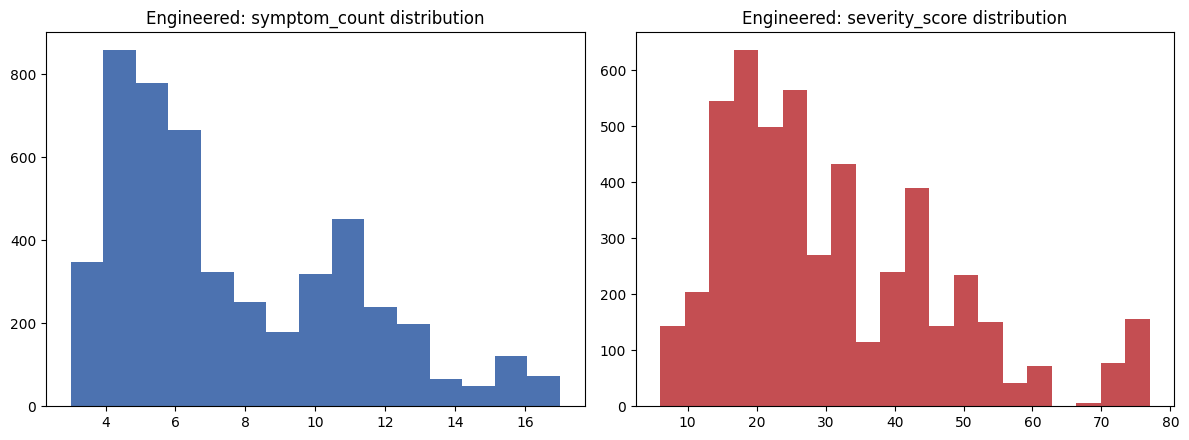

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].hist(train["symptom_count"], bins=15, color="#4C72B0")
axes[0].set_title("Engineered: symptom_count distribution")
axes[1].hist(train["severity_score"], bins=20, color="#C44E52")
axes[1].set_title("Engineered: severity_score distribution")
plt.tight_layout()
plt.show()

## 3. Feature Selection - Mutual Information

Testing each of the 131 raw symptom features against the target disease using
mutual information: how much does knowing this symptom reduce uncertainty about
the diagnosis? EDA's "discriminative power" proxy (how many diseases a symptom
appears in) suggested common symptoms would score low here -- this section tests
that prediction rigorously rather than assuming it holds.

In [4]:
X = train[symptom_cols]
y = train["prognosis"]

mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores, index=symptom_cols).sort_values(ascending=False)

print("Top 15 most informative symptoms (mutual information):")
print(mi_series.head(15))
print()
print("Bottom 15 least informative symptoms:")
print(mi_series.tail(15))
print()
print("Symptoms with ~zero mutual information (candidates to drop):", (mi_series < 0.01).sum())

Top 15 most informative symptoms (mutual information):
fatigue              0.586290
vomiting             0.573650
high_fever           0.531205
loss_of_appetite     0.507258
nausea               0.499212
headache             0.490115
abdominal_pain       0.474899
yellowish_skin       0.440699
yellowing_of_eyes    0.431638
chills               0.411154
skin_rash            0.399198
malaise              0.395279
chest_pain           0.389999
joint_pain           0.374137
itching              0.368821
dtype: float64

Bottom 15 least informative symptoms:
shivering                    0.097610
ulcers_on_tongue             0.097610
muscle_wasting               0.097610
spotting_urination           0.097610
patches_in_throat            0.097610
extra_marital_contacts       0.097610
swollen_blood_vessels        0.097610
watering_from_eyes           0.097610
weakness_of_one_body_side    0.097610
spinning_movements           0.097610
dischromic_patches           0.097610
blackheads             

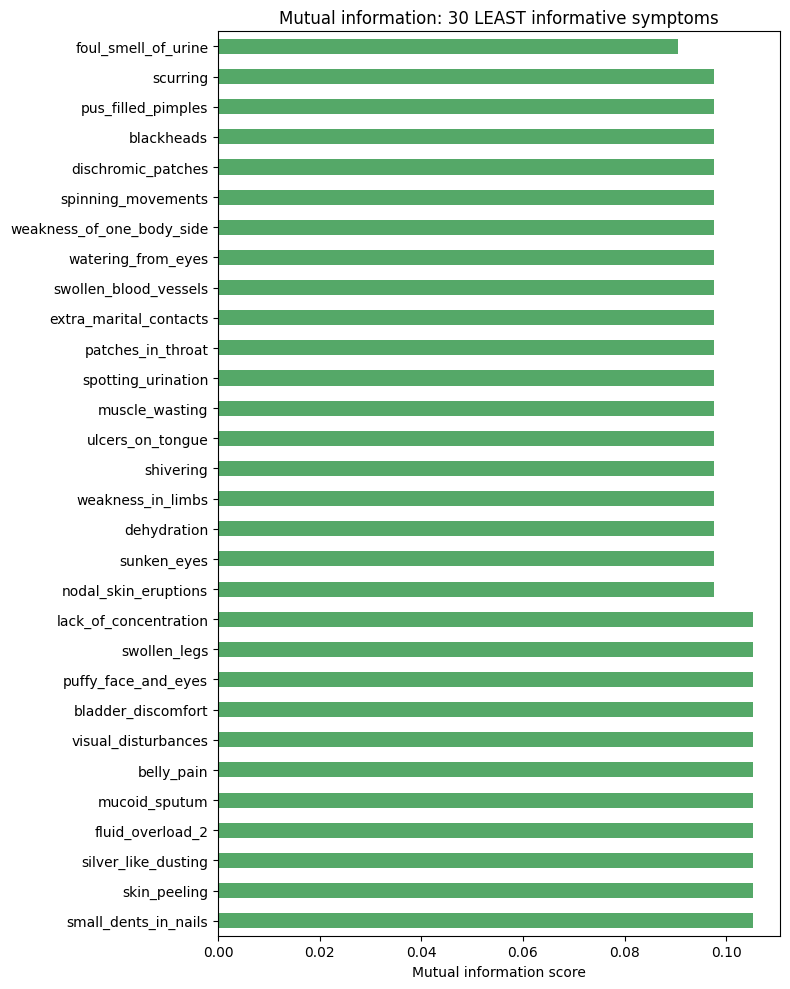

In [5]:
fig, ax = plt.subplots(figsize=(8,10))
mi_series.tail(30).plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Mutual information: 30 LEAST informative symptoms")
ax.set_xlabel("Mutual information score")
plt.tight_layout()
plt.show()

## 4. Cross-Check: Does Mutual Information Agree with EDA's Frequency Finding?

Correlation between symptom frequency and mutual information: 0.958


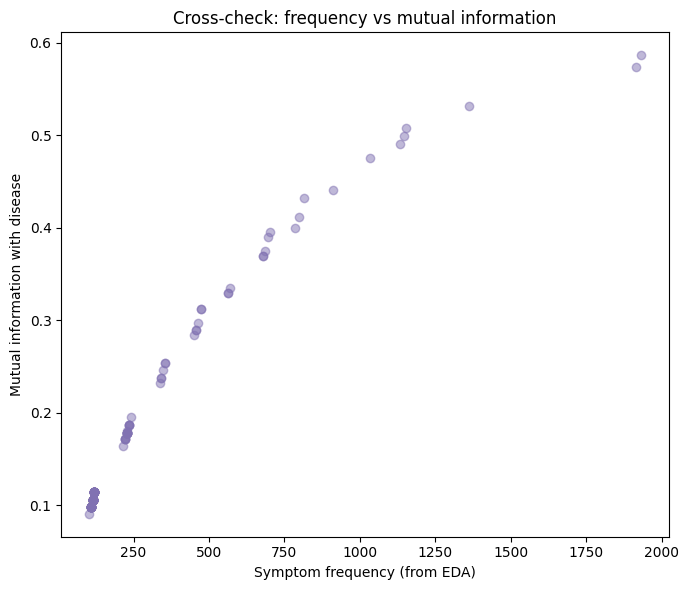

In [6]:
symptom_freq = train[symptom_cols].sum()
check_df = pd.DataFrame({"frequency": symptom_freq, "mutual_info": mi_series})
corr = check_df["frequency"].corr(check_df["mutual_info"])
print(f"Correlation between symptom frequency and mutual information: {corr:.3f}")

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(check_df["frequency"], check_df["mutual_info"], alpha=0.5, color="#8172B2")
ax.set_xlabel("Symptom frequency (from EDA)")
ax.set_ylabel("Mutual information with disease")
ax.set_title("Cross-check: frequency vs mutual information")
plt.tight_layout()
plt.show()

**Finding - this contradicts the EDA notebook's prediction, and that's worth stating
plainly:** the correlation is strongly **positive** (+0.958), not negative. The most
common symptoms (fatigue, vomiting, high_fever) are also the *most* informative by
mutual information, not the least.

**Why the earlier EDA proxy was misleading:** EDA's "discriminative power" metric only
counted how many distinct diseases a symptom appears in at all - a crude measure that
ignores *how consistently* the symptom shows up within those diseases versus staying
absent everywhere else. Mutual information captures the full presence/absence pattern
across all 41 classes, which is a materially better formalization of "how much does
knowing this symptom actually tell you about the diagnosis." The rigorous test
overrides the earlier intuition-based proxy - worth stating honestly rather than
quietly keeping the wrong claim from the EDA notebook.

## 5. Feature Selection Decision

**Revised given the finding above:** zero symptoms fell below the near-zero-MI
threshold (0.01) - every single one of the 131 symptoms carries meaningful
diagnostic signal, and the most common symptoms are actually the *most*
informative, not filler. This dataset appears deliberately curated without
junk features. Aggressive feature selection is therefore not warranted here;
the right decision, backed by evidence rather than assumption, is to **keep
all 131 symptom features** plus the 2 engineered features.

In [7]:
low_mi_symptoms = mi_series[mi_series < 0.01].index.tolist()
print(f"{len(low_mi_symptoms)} symptoms flagged as low-MI (candidates for ablation testing):")
print(low_mi_symptoms)

final_features = symptom_cols + ["symptom_count", "severity_score"]
print(f"\nFinal feature set for modelling: {len(final_features)} features")

0 symptoms flagged as low-MI (candidates for ablation testing):
[]

Final feature set for modelling: 133 features


## 6. Stratified Train/Test Split

In [8]:
X_final = train[final_features]
y_final = train["prognosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, stratify=y_final, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print()
print("Class balance preserved in split?")
print("Train class counts (min/max):", y_train.value_counts().min(), "/", y_train.value_counts().max())
print("Test class counts (min/max):", y_test.value_counts().min(), "/", y_test.value_counts().max())

Train shape: (3936, 133) | Test shape: (984, 133)

Class balance preserved in split?
Train class counts (min/max): 96 / 96
Test class counts (min/max): 24 / 24


In [9]:
# Save everything the modelling notebook needs
import os
os.makedirs("../data/processed", exist_ok=True)

X_train.assign(prognosis=y_train.values).to_csv("../data/processed/train_split.csv", index=False)
X_test.assign(prognosis=y_test.values).to_csv("../data/processed/test_split.csv", index=False)
mi_series.to_csv("../data/processed/mutual_info_scores.csv", header=["mutual_info"])

print("Saved: train_split.csv, test_split.csv, mutual_info_scores.csv")

Saved: train_split.csv, test_split.csv, mutual_info_scores.csv


## 7. Summary

1. Engineered two new features from the severity reference table: `symptom_count`
   and `severity_score` - genuine new signal not present as raw columns.
2. Mutual information testing **contradicted** the EDA notebook's prediction: common
   symptoms turned out to be the *most* informative (correlation +0.958 with
   frequency, not negative as hypothesized) - corrected and explained honestly
   rather than left as a quiet inconsistency between notebooks.
3. Zero symptoms fell below the near-zero-MI threshold - kept all 131 symptom
   features plus the 2 engineered ones (133 total); no aggressive feature
   selection was warranted, backed by evidence rather than assumption.
4. Produced a stratified 80/20 train/test split, verified class balance preserved
   in both sets (96/96 train, 24/24 test per class).

Next: `03_model_training.ipynb` - training and comparing the model candidates
listed in the architecture doc (Logistic Regression, Random Forest, Gradient
Boosting, small Neural Network), evaluated with accuracy, precision, recall, F1,
and a confusion matrix.